In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import cv2 as cv
import matplotlib.colors as mcolors

from matplotlib import colors
import cartopy  # Map projections libary
import cartopy.crs as ccrs  # Projections list
import datetime
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import (LATITUDE_FORMATTER,LONGITUDE_FORMATTER)

import matplotlib.path as mpath
import matplotlib.ticker as ticker

matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

/home/lsaddier/miniforge3/lib/python3.10/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [3]:
# Open useful datasets

# T and S vertical profiles
T_S_Burgard = xr.open_dataset("../Datasets/T_S_mean_prof_corrected_km_contshelf_and_offshore_1980-2018_oneFRIS.nc")

# Masks for defining ice shelves and front lines
IS_mask_Burgard = xr.open_dataset("../Datasets/nemo_5km_isf_masks_and_info_and_distance_new_oneFRIS.nc")


In [4]:
# Let define isf of interest

index_isf = np.array([10,11,31,52,66,43,45,48,33])
def index2name(N):
    return IS_mask_Burgard.isf_name.sel(Nisf = N).values

name_isf =[]
for N in index_isf:
    name_isf.append(index2name(N))
name_isf = np.array(name_isf)
# ['Ross', 'Filchner-Ronne', 'Amery', 'Dotson', 'Pine Island', 'Thwaites', 'Riiser-Larsen', 'Roi Baudouin', 'Totten']

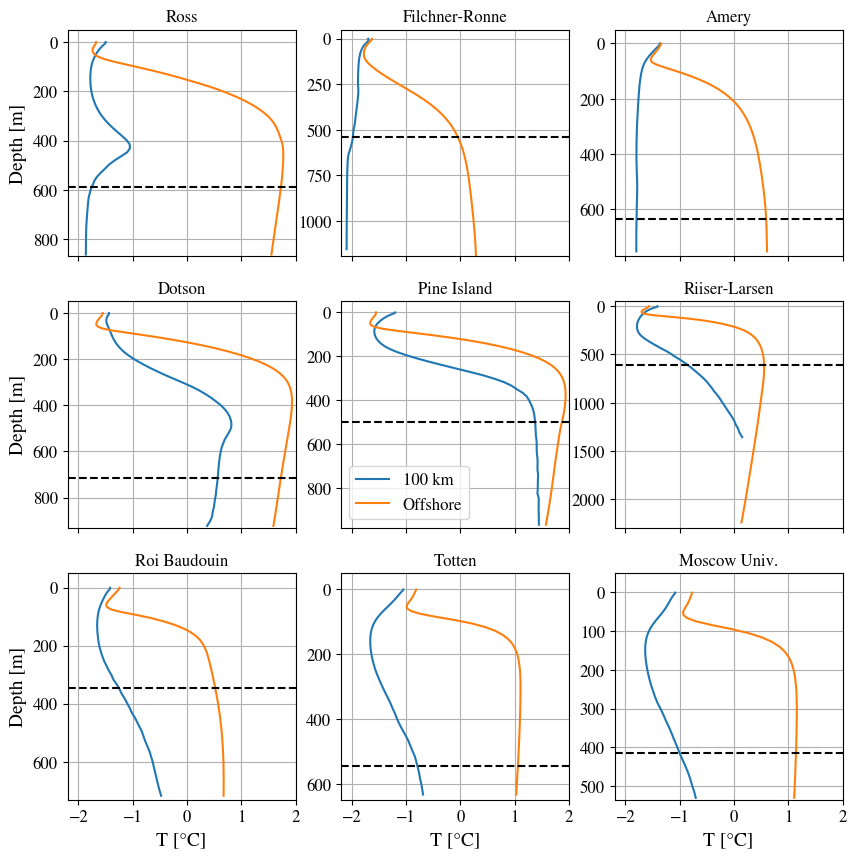

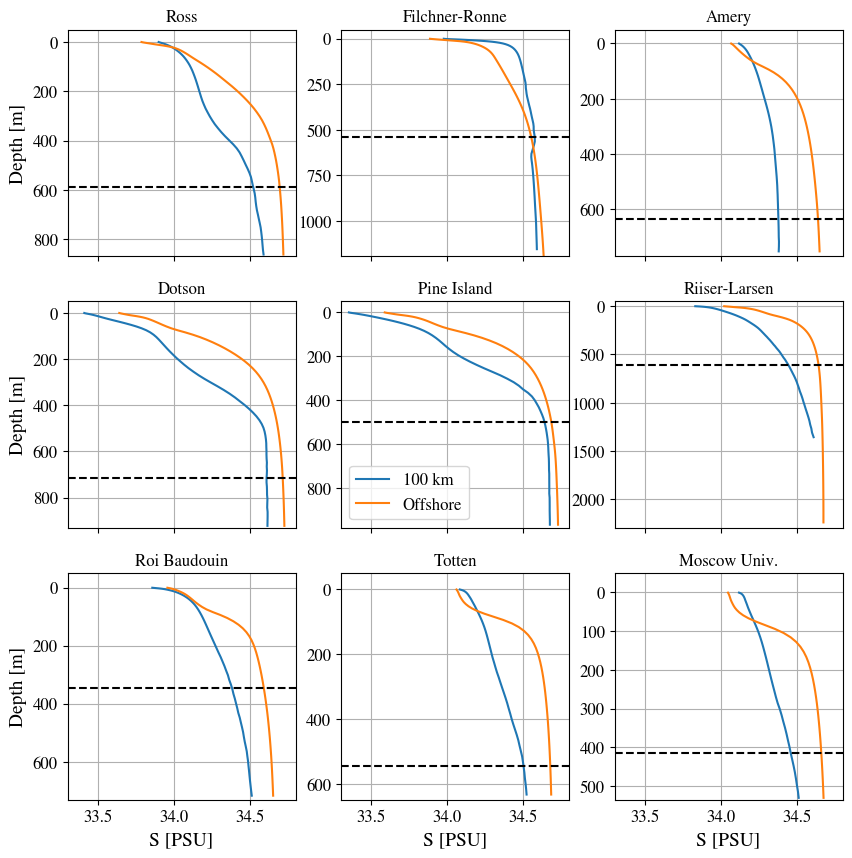

In [6]:
# T-S profiles

fig, ax =plt.subplots(3,3,figsize=(10,10),sharex=True)

for k, index, name in zip(np.arange(9),index_isf,name_isf):

    d_avg = IS_mask_Burgard.sel(Nisf=index).front_bot_depth_avg.values
    d_max = IS_mask_Burgard.sel(Nisf=index).front_bot_depth_max.values
    depth = T_S_Burgard.depth.where(T_S_Burgard.depth<d_max)

    i = k//3
    j = k%3
    
    for dist in [100,1000]:
        T_prof = T_S_Burgard.sel(Nisf=index).where(T_S_Burgard.depth<d_max).theta_ocean.mean(dim='time').sel(profile_domain=dist).values
        ax[i,j].plot(T_prof,depth)
        
    ax[i,j].set_ylim((-50,d_max))
    ax[i,j].invert_yaxis()
    ax[i,j].axhline(d_avg, c='black', linestyle='dashed')
    ax[i,j].set_title(name)
    
    ax[i,j].xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax[i,j].grid()
    ax[i,j].set_xlim(-2.2,2)

    if i==2:
        ax[i,j].set_xlabel('T [°C]')
    if j==0:
        ax[i,j].set_ylabel('Depth [m]')

ax[1,1].legend(['100 km','Offshore'])

plt.savefig('Figures/T_profile.pdf')
plt.show()


print('   ')
print('   ')

fig, ax =plt.subplots(3,3,figsize=(10,10),sharex=True)

for k, index, name in zip(np.arange(9),index_isf,name_isf):

    d_avg = IS_mask_Burgard.sel(Nisf=index).front_bot_depth_avg.values
    d_max = IS_mask_Burgard.sel(Nisf=index).front_bot_depth_max.values
    depth = T_S_Burgard.depth.where(T_S_Burgard.depth<d_max)

    i = k//3
    j = k%3
    
    for dist in [100,1000]:
        T_prof = T_S_Burgard.sel(Nisf=index).where(T_S_Burgard.depth<d_max).salinity_ocean.mean(dim='time').sel(profile_domain=dist).values
        ax[i,j].plot(T_prof,depth)
        
    ax[i,j].set_ylim((-50,d_max))
    ax[i,j].invert_yaxis()
    ax[i,j].axhline(d_avg, c='black', linestyle='dashed')
    ax[i,j].set_title(name)
    ax[i,j].grid()
    ax[i,j].set_xlim(33.3,34.8)

    if i==2:
        ax[i,j].set_xlabel('S [PSU]')
    if j==0:
        ax[i,j].set_ylabel('Depth [m]')

ax[1,1].legend(['100 km','Offshore'])
plt.savefig('Figures/S_profile.pdf')
plt.show()